# Imports and configuration

In [6]:
!pip3 install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [37]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import custom helper functions
sys.path.append('../utils')
from myutils import display_report, plot_categorical_dual, plot_numeric_report

print("Libraries loaded.")

Библиотеки загружены.
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# 2. Loading raw data

In [38]:
import os
os.getcwd()

'/Users/vladailchuk/Desktop/ITC/final_project/notebooks'

In [39]:
RAW_PATH   = "../data/raw/Contacts (Done).xlsx"
CLEAN_PATH = "../data/clean/contacts_clean.pkl"

df = pd.read_excel(RAW_PATH)

print(f"Dataset size: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Размер датасета: (18548, 4)
Столбцы: ['Id', 'Contact Owner Name', 'Created Time', 'Modified Time']


,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17


# 3. Initial data overview

In [40]:
# Reviewing data types, missing values, and unique values
display_report(df, df_name="Contacts (raw)")

  ОТЧЁТ: Contacts (raw)
  Размер : 18,548 строк × 4 столбцов
  Память : 2.07 MB

  Пропусков нет.

  КАТЕГОРИАЛЬНЫЕ столбцы:
            column  dtype  n_unique        top_value  top_freq  top_pct  null_count  null_pct
Contact Owner Name object        28    Charlie Davis      2018    10.88           0       0.0
      Created Time    str     17921 10.06.2024 09:00        13     0.07           0       0.0
     Modified Time    str     16580 13.06.2024 17:08        25     0.13           0       0.0

  ЧИСЛОВЫЕ столбцы:
column  count         mean       median                mode         std                 min                 max    range  null_count  null_pct
    Id  18548 5.805028e+18 5.805028e+18 5805028000000645014 15663053.22 5805028000000645014 5805028000056907001 56261987           0       0.0


# 4. Date conversion

In [41]:
# pd.to_datetime with errors='coerce' converts invalid dates into NaT instead of raising an error

df["Created Time"]  = pd.to_datetime(df["Created Time"],  errors="coerce")
df["Modified Time"] = pd.to_datetime(df["Modified Time"], errors="coerce")

# Add separate columns containing only the date (without time)
# for convenient grouping by month
df["create_date"] = df["Created Time"].dt.normalize()
df["modified_date"] = df["Modified Time"].dt.normalize()

print("Date types after conversion:")
print(df[["Created Time", "Modified Time", "create_date", "modified_date"]].dtypes)

Типы дат после конвертации:
Created Time     datetime64[us]
Modified Time    datetime64[us]
create_date      datetime64[us]
modified_date    datetime64[us]
dtype: object


In [42]:
df

,Id,Contact Owner Name,Created Time,Modified Time,create_date,modified_date
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,2023-06-27,2023-12-22
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,2023-07-03,2024-05-21
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,2023-07-02,2023-12-21
3,5805028000000907006,Bob Brown,2023-07-03 05:44:00,2023-12-29 15:20:00,2023-07-03,2023-12-29
4,5805028000000939010,Nina Scott,2023-07-04 10:11:00,2024-04-16 16:14:00,2023-07-04,2024-04-16
...,...,...,...,...,...,...
18543,5805028000056889209,Ulysses Adams,2024-06-21 12:11:00,2024-06-21 14:11:00,2024-06-21,2024-06-21
18544,5805028000056889351,Eva Kent,2024-06-21 13:32:00,2024-06-21 15:32:00,2024-06-21,2024-06-21
18545,5805028000056892018,Eva Kent,2024-06-21 10:21:00,2024-06-21 12:21:00,2024-06-21,2024-06-21
18546,5805028000056892055,Yara Edwards,2024-06-21 10:22:00,2024-06-21 12:23:00,2024-06-21,2024-06-21


# 5. Missing values handling

In [43]:
print("Missing values before cleaning:")
print(df.isna().sum())

Пропуски до очистки:
Id                    0
Contact Owner Name    0
Created Time          0
Modified Time         0
create_date           0
modified_date         0
dtype: int64


In [44]:
# Contact owner: replace missing values with 'Unknown'
df["Contact Owner Name"] = df["Contact Owner Name"].fillna("Unknown")

# ID should not contain missing values — validate
assert df["Id"].isna().sum() == 0, "ERROR: Id column contains missing values!"

print("\nMissing values after cleaning:")
print(df.isna().sum())


Пропуски после очистки:
Id                    0
Contact Owner Name    0
Created Time          0
Modified Time         0
create_date           0
modified_date         0
dtype: int64


In [45]:
df["Contact Owner Name"].unique()

array(['Rachel White', 'Charlie Davis', 'Bob Brown', 'Nina Scott',
       'Alice Johnson', 'Ian Miller', 'Jane Smith', 'Julia Nelson',
       'George King', 'Quincy Vincent', 'Diana Evans', 'Kevin Parker',
       'Ulysses Adams', 'Victor Barnes', 'Yara Edwards',
       'Paula Underwood', 'Mason Roberts', 'Ben Hall', 'Amy Green',
       'Cara Iverson', 'Oliver Taylor', 'Eva Kent', False,
       'Zachary Foster', 'Sam Young', 'Wendy Clark', 'Tina Zhang',
       'Derek James'], dtype=object)

In [46]:
df["Contact Owner Name"] = df["Contact Owner Name"].replace([False, "FALSE", ""], "Unknown")

In [47]:
df[df["Contact Owner Name"] == "Unknown"]

,Id,Contact Owner Name,Created Time,Modified Time,create_date,modified_date
2197,5805028000008772190,Unknown,2023-09-24 09:01:00,2023-10-13 16:44:00,2023-09-24,2023-10-13


In [48]:
df["Contact Owner Name"].value_counts()

Contact Owner Name
Charlie Davis      2018
Ulysses Adams      1816
Julia Nelson       1769
Paula Underwood    1487
Quincy Vincent     1416
Nina Scott         1150
Ben Hall           1038
Victor Barnes       967
Cara Iverson        880
Rachel White        782
Jane Smith          754
Bob Brown           685
Ian Miller          684
Diana Evans         678
Yara Edwards        655
Amy Green           621
Eva Kent            365
Kevin Parker        325
Mason Roberts       217
George King         144
Sam Young            37
Alice Johnson        27
Oliver Taylor        19
Zachary Foster        8
Wendy Clark           2
Tina Zhang            2
Unknown               1
Derek James           1
Name: count, dtype: int64

# 6. Removing duplicates

In [49]:
dups = df.duplicated(subset=["Id"]).sum()
print(f"Duplicate IDs: {dups}")

Дублирующихся id: 0


In [50]:
df = df.drop_duplicates(subset=["Id"]).reset_index(drop=True)
print(f"Dataset size after removing duplicates: {df.shape}")

Размер после удаления дубликатов: (18548, 6)


# 7. Optimizing data types (memory optimization)

In [51]:
# Convert the Id column to string type because:
# - Id is NOT used for numerical calculations
# - It is a unique identifier (similar to a passport number)
# - This approach is safer (prevents losing leading zeros and accidental calculations)
df["Id"] = df["Id"].astype("string")

# Convert Contact Owner Name to category type because:
# - It contains repeated values (manager names)
# - Category type reduces memory usage
# - It speeds up operations such as groupby / value_counts
df["Contact Owner Name"] = df["Contact Owner Name"].astype("category")

print("Data types:")
print(df.dtypes)

# Calculate the total memory usage of the DataFrame (in KB)
# deep=True is required to include the actual memory used by strings
# this helps evaluate optimization after changing data types
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Типы данных:
Id                            string
Contact Owner Name          category
Created Time          datetime64[us]
Modified Time         datetime64[us]
create_date           datetime64[us]
modified_date         datetime64[us]
dtype: object

Память: 1087.5 KB


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  18548 non-null  string        
 1   Contact Owner Name  18548 non-null  category      
 2   Created Time        18548 non-null  datetime64[us]
 3   Modified Time       18548 non-null  datetime64[us]
 4   create_date         18548 non-null  datetime64[us]
 5   modified_date       18548 non-null  datetime64[us]
dtypes: category(1), datetime64[us](4), string(1)
memory usage: 1.1 MB


# 8. Feature Engineering \ Creating a new feature: modification delay in days

In [53]:
df["modification_delay_days"] = (df["Modified Time"] - df["Created Time"]).dt.days.fillna(0).astype("int64")

print("New feature 'modification_delay_days':")
print(df["modification_delay_days"].describe())

Новый признак 'modification_delay_days':
count    18548.000000
mean        21.489379
std         53.392838
min          0.000000
25%          0.000000
50%          0.000000
75%          6.000000
max        350.000000
Name: modification_delay_days, dtype: float64


In [54]:
# Calculated the difference between dates
# Converted the result into days
# Filled missing values
# Converted the feature to numeric type
# Analyzed the distribution

df

,Id,Contact Owner Name,Created Time,Modified Time,create_date,modified_date,modification_delay_days
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,2023-06-27,2023-12-22,178
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,2023-07-03,2024-05-21,322
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,2023-07-02,2023-12-21,171
3,5805028000000907006,Bob Brown,2023-07-03 05:44:00,2023-12-29 15:20:00,2023-07-03,2023-12-29,179
4,5805028000000939010,Nina Scott,2023-07-04 10:11:00,2024-04-16 16:14:00,2023-07-04,2024-04-16,287
...,...,...,...,...,...,...,...
18543,5805028000056889209,Ulysses Adams,2024-06-21 12:11:00,2024-06-21 14:11:00,2024-06-21,2024-06-21,0
18544,5805028000056889351,Eva Kent,2024-06-21 13:32:00,2024-06-21 15:32:00,2024-06-21,2024-06-21,0
18545,5805028000056892018,Eva Kent,2024-06-21 10:21:00,2024-06-21 12:21:00,2024-06-21,2024-06-21,0
18546,5805028000056892055,Yara Edwards,2024-06-21 10:22:00,2024-06-21 12:23:00,2024-06-21,2024-06-21,0


# 9. Final report on cleaned data

In [55]:
display_report(df, df_name="Contacts (clean)")

  ОТЧЁТ: Contacts (clean)
  Размер : 18,548 строк × 7 столбцов
  Память : 1.20 MB

  Пропусков нет.

  КАТЕГОРИАЛЬНЫЕ столбцы:
            column    dtype  n_unique     top_value  top_freq  top_pct  null_count  null_pct
Contact Owner Name category        28 Charlie Davis      2018    10.88           0       0.0

  ЧИСЛОВЫЕ столбцы:
                 column  count  mean  median  mode   std  min  max  range  null_count  null_pct
modification_delay_days  18548 21.49     0.0     0 53.39    0  350    350           0       0.0


# 10. Visualization: top managers

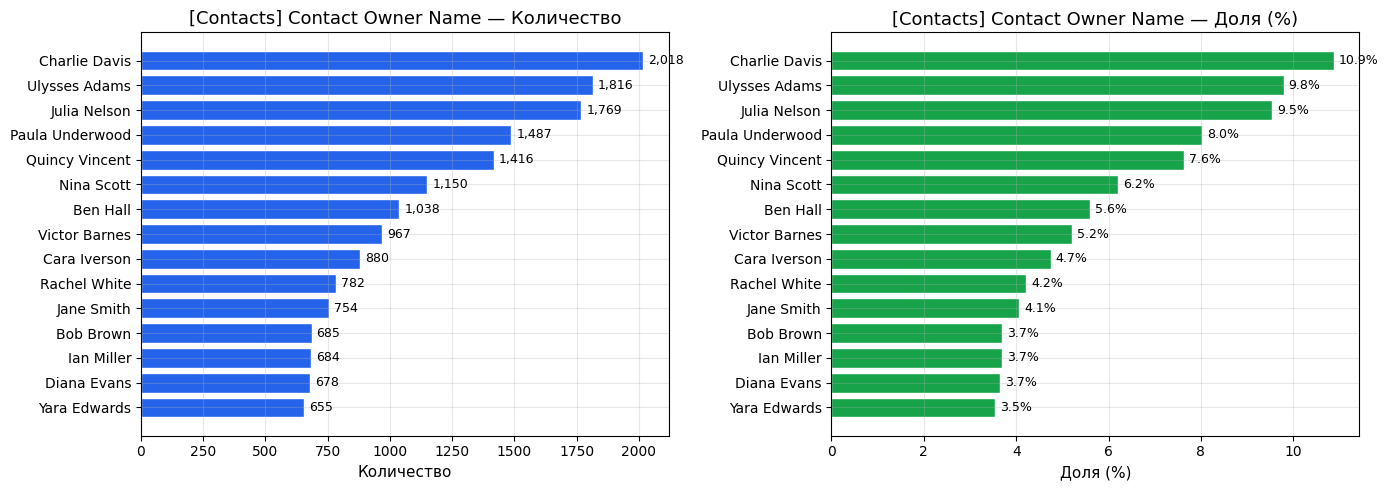

In [56]:
plot_categorical_dual(df["Contact Owner Name"], col_name="Contact Owner Name", df_name="Contacts", top_n=15)

# 11. Visualization: contact creation dynamics

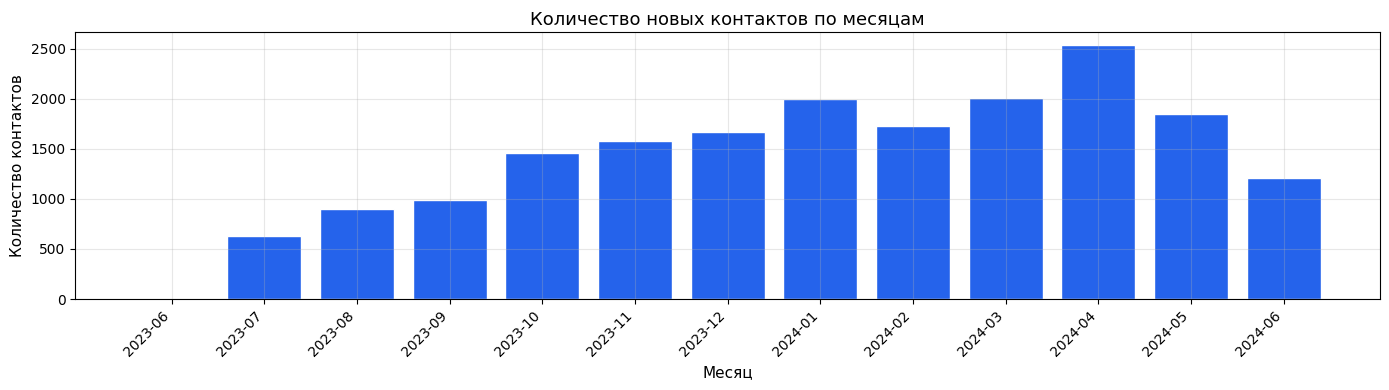

Пиковый месяц: 2024-04 — 2,535 контактов


In [57]:
monthly = (df.groupby(df["Created Time"].dt.to_period("M")).size().reset_index(name="count"))
monthly["month"] = monthly["Created Time"].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(monthly["month"], monthly["count"], color="#2563EB", edgecolor="white")

ax.set_title("Number of new contacts by month", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Number of contacts")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

peak = monthly.loc[monthly["count"].idxmax()]
print(f"Peak month: {peak['month']} — {peak['count']:,} contacts")

# 12. Saving cleaned dataset
## The pkl format preserves data types (unlike csv)

In [ ]:
# 1. Separation of stages
#    raw = unprocessed data
#    clean = processed data

# 2. Time efficiency
#    No need to clean the data from scratch every time

In [58]:
df.to_pickle(CLEAN_PATH)

print(f"File saved: {CLEAN_PATH}")
print(f"Final size: {df.shape}")

df.info()

Файл сохранён: ../data/clean/contacts_clean.pkl
Итоговый размер: (18548, 7)
<class 'pandas.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Id                       18548 non-null  string        
 1   Contact Owner Name       18548 non-null  category      
 2   Created Time             18548 non-null  datetime64[us]
 3   Modified Time            18548 non-null  datetime64[us]
 4   create_date              18548 non-null  datetime64[us]
 5   modified_date            18548 non-null  datetime64[us]
 6   modification_delay_days  18548 non-null  int64         
dtypes: category(1), datetime64[us](4), int64(1), string(1)
memory usage: 1.2 MB
